In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

In [4]:
df = pd.read_csv("../data/processed/logistics_preprocessed.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (249231, 21)
   Route ID  Driver ID  Stop ID  Address ID  Week ID  Country Day of Week  \
0         0          0        0           0        0        1      Monday   
1         0          0        1           1        0        1     Tuesday   
2         0          0        2           2        0        1     Tuesday   
3         0          0        3           3        0        1      Monday   
4         0          0        4           3        0        1      Monday   

   IndexP  IndexA  Arrived Time  ...  Latest Time  DistanceP  DistanceA  \
0       0       0        42.275  ...        360.0   0.000000   0.000000   
1       1       4       332.788  ...        480.0  16.329053  16.329053   
2       2       5       332.956  ...        540.0   0.373110   0.373110   
3       3       2       244.994  ...        540.0   2.491915   0.000000   
4       4       1       244.855  ...        540.0   0.000000  13.944962   

   Depot  Delivery  Route Deviation  DistanceP_Normalized 

In [5]:
print(df.columns.tolist())

['Route ID', 'Driver ID', 'Stop ID', 'Address ID', 'Week ID', 'Country', 'Day of Week', 'IndexP', 'IndexA', 'Arrived Time', 'Earliest Time', 'Latest Time', 'DistanceP', 'DistanceA', 'Depot', 'Delivery', 'Route Deviation', 'DistanceP_Normalized', 'DistanceA_Normalized', 'DistanceP_Standardized', 'DistanceA_Standardized']


In [6]:
target = "DistanceA"

In [7]:
features = [
    "DistanceP",
    "IndexP",
    "Week ID",
    "Country",
    "Day of Week",
    "Depot",
    "Delivery"
]

X = df[features]
y = df["DistanceA"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['DistanceP', 'IndexP', 'Week ID', 'Country', 'Day of Week', 'Depot',
       'Delivery'],
      dtype='str')

Target:
DistanceA


In [8]:
numeric_features = [
    "DistanceP",
    "IndexP",
    "Week ID"
]

categorical_features = [
    "Country",
    "Day of Week",
    "Depot",
    "Delivery"
]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (199384, 7)
Testing data: (49847, 7)


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [11]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [12]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("-----------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
-----------------------
MAE : 2.42684412749261
RMSE: 6.951269541284397
R²  : 0.7653968404690591


In [13]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [14]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("-----------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
-----------------------
MAE : 2.453332464419805
RMSE: 6.486242746516739
R²  : 0.7957359235159754


In [15]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

print(results)

               Model       MAE      RMSE        R2
0  Linear Regression  2.426844  6.951270  0.765397
1      Random Forest  2.453332  6.486243  0.795736


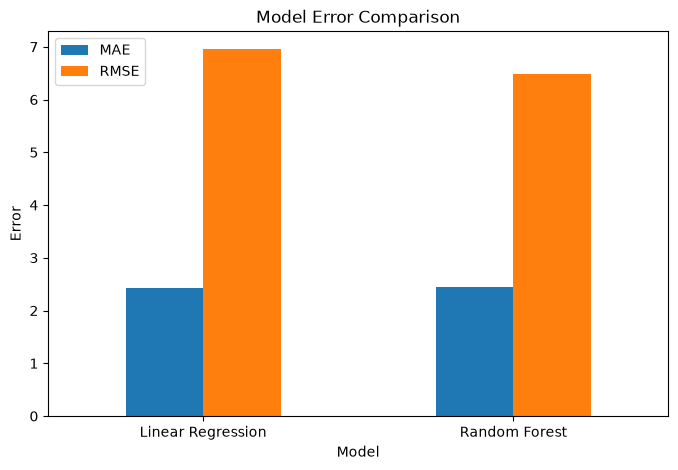

In [16]:
results_plot = results.set_index("Model")

results_plot[
    ["MAE", "RMSE"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

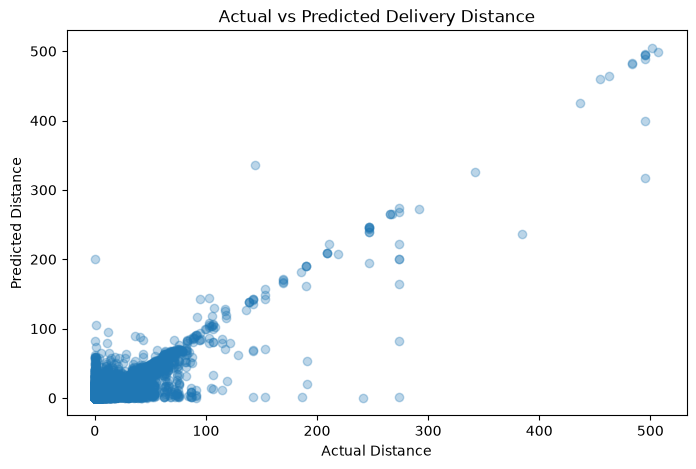

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

plt.xlabel("Actual Distance")
plt.ylabel("Predicted Distance")

plt.title(
    "Actual vs Predicted Delivery Distance"
)

plt.show()

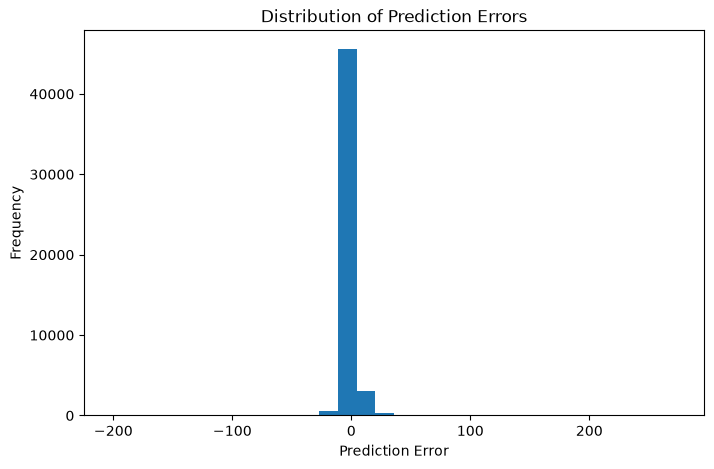

In [18]:
errors = y_test - rf_pred

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Prediction Errors"
)

plt.show()

In [19]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:")
print(cv_scores)

print(
    "Mean CV R²:",
    cv_scores.mean()
)

Cross-validation R² scores:
[0.77856187 0.76099368 0.7826932 ]
Mean CV R²: 0.7740829151126191


In [20]:
from sklearn.model_selection import RandomizedSearchCV

In [21]:
param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [22]:
# Use a smaller sample only for hyperparameter tuning

tune_size = 30000

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=tune_size,
    random_state=42
)

print("Tuning dataset shape:", X_tune.shape)

Tuning dataset shape: (30000, 7)


In [23]:
# Use a smaller sample only for hyperparameter tuning

tune_size = 30000

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=tune_size,
    random_state=42
)

print("Tuning dataset shape:", X_tune.shape)

Tuning dataset shape: (30000, 7)


In [24]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, 15],
    "model__min_samples_split": [2, 5]
}

In [25]:
random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_grid,
    n_iter=4,
    cv=2,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

In [26]:
random_search.fit(
    X_tune,
    y_tune
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 15], 'model__min_samples_split': [2, 5], 'model__n_estimators': [50, 100]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metri

In [27]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_depth': 10}

Best CV MAE:
2.647484926410242


In [28]:
best_params = random_search.best_params_

final_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=best_params["model__n_estimators"],
                max_depth=best_params["model__max_depth"],
                min_samples_split=best_params["model__min_samples_split"],
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [29]:
final_rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['DistanceP','IndexP','Week ID',...,'Day of Week','Depot','Delivery']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis c

In [31]:
final_pred = final_rf_model.predict(X_test)

In [32]:
final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("FINAL TUNED RANDOM FOREST")
print("----------------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

FINAL TUNED RANDOM FOREST
----------------------------
MAE : 2.533684200530325
RMSE: 6.540542899200972
R²  : 0.7923015785473035


In [33]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        final_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        final_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        final_r2
    ]
})

print(final_results)

                 Model       MAE      RMSE        R2
0    Linear Regression  2.426844  6.951270  0.765397
1        Random Forest  2.453332  6.486243  0.795736
2  Tuned Random Forest  2.533684  6.540543  0.792302
